In [1]:
import sys, json, os
sys.path.append("..")
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from src.robustness import run_scenarios

pipe = joblib.load("../models/final_xgb_pipeline.joblib")
X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test = pd.read_parquet("../data/processed/X_test.parquet")
y_test = pd.read_parquet("../data/processed/y_test.parquet")["_MICHD"].values
final = json.load(open("../reports/final_features.json"))["final"]
t = json.load(open("../reports/final_decision.json"))["flag_threshold"]

ordinal_cols = ["_AGE_G", "GENHLTH", "INCOME3"]
ranges = {c: (X_train[c].min(), X_train[c].max()) for c in ordinal_cols}
print(ranges)        # expect age 1-6, general health 1-5, income 1-11

{'_AGE_G': (np.float64(1.0), np.float64(6.0)), 'GENHLTH': (np.float64(1.0), np.float64(5.0)), 'INCOME3': (np.float64(1.0), np.float64(11.0))}


In [2]:
res = run_scenarios(pipe, X_test, y_test, final, t, ordinal_cols, ranges)
os.makedirs("../reports", exist_ok=True)
res.to_csv("../reports/robustness_results.csv", index=False)
base = res[res.scenario == "clean"].iloc[0]
print("clean:", base[["roc_auc", "pr_auc", "recall", "precision", "flagged_pct"]].round(4).to_dict())

clean: {'roc_auc': 0.8318, 'pr_auc': 0.3412, 'recall': 0.7978, 'precision': 0.2213, 'flagged_pct': 33.7374}


In [3]:
g = res[~res.scenario.isin(["clean", "knockout"])].groupby(["scenario", "level"])
tbl = g[["roc_auc", "pr_auc", "recall", "precision", "flagged_pct"]].mean()
tbl["roc_auc_std"] = g["roc_auc"].std()
tbl["roc_auc_drop"] = base["roc_auc"] - tbl["roc_auc"]
tbl.round(4)

roc_auc  pr_auc  recall  precision  flagged_pct  \
scenario          level                                                    
missing_cells     0.05    0.8265  0.3328  0.7920     0.2187      33.8875   
                  0.10    0.8212  0.3251  0.7850     0.2161      33.9938   
                  0.20    0.8093  0.3082  0.7677     0.2107      34.1012   
                  0.30    0.7953  0.2909  0.7442     0.2040      34.1425   
                  0.40    0.7802  0.2717  0.7209     0.1983      34.0285   
noise_PHYSHLTH    0.10    0.8318  0.3414  0.7973     0.2213      33.7162   
                  0.25    0.8316  0.3412  0.8009     0.2202      34.0327   
                  0.50    0.8314  0.3410  0.8044     0.2190      34.3744   
ordinal_misreport 0.05    0.8303  0.3390  0.7938     0.2210      33.6064   
                  0.10    0.8289  0.3368  0.7900     0.2208      33.4726   
                  0.20    0.8258  0.3319  0.7815     0.2201      33.2269   
                  0.30    0.8229  0.3273  0.7739     0.2196      32.9727   

                         roc_auc_std  roc_auc_drop  
scenario          level                             
missing_cells     0.05        0.0002        0.0052  
                  0.10        0.0006        0.0105  
                  0.20        0.0011        0.0225  
                  0.30        0.0006        0.0365  
                  0.40        0.0009        0.0516  
noise_PHYSHLTH    0.10        0.0001        0.0000  
                  0.25        0.0001        0.0002  
                  0.50        0.0001        0.0004  
ordinal_misreport 0.05        0.0002        0.0014  
                  0.10        0.0004        0.0029  
                  0.20        0.0004        0.0060  
                  0.30        0.0003        0.0089

In [4]:
ko = res[res.scenario == "knockout"].set_index("level")[["roc_auc", "pr_auc", "recall", "flagged_pct"]]
ko["roc_auc_drop"] = base["roc_auc"] - ko["roc_auc"]
ko.sort_values("roc_auc_drop", ascending=False).round(4)

,roc_auc,pr_auc,recall,flagged_pct,roc_auc_drop
level,,,,,
_AGE_G,0.7964,0.3119,0.6907,29.0266,0.0353
GENHLTH,0.8129,0.3054,0.8279,39.3776,0.0189
SEXVAR,0.8191,0.3202,0.7474,31.0665,0.0126
CHCKDNY2,0.8286,0.3310,0.8569,40.2451,0.0031
DIABETE4,0.8289,0.3343,0.8194,36.1630,0.0028
CHCCOPD3,0.8290,0.3331,0.8589,40.1302,0.0027
HAVARTH4,0.8302,0.3389,0.7704,31.3317,0.0016
_SMOKER3,0.8303,0.3396,0.8054,34.7496,0.0015
INCOME3,0.8305,0.3394,0.7939,33.4578,0.0013


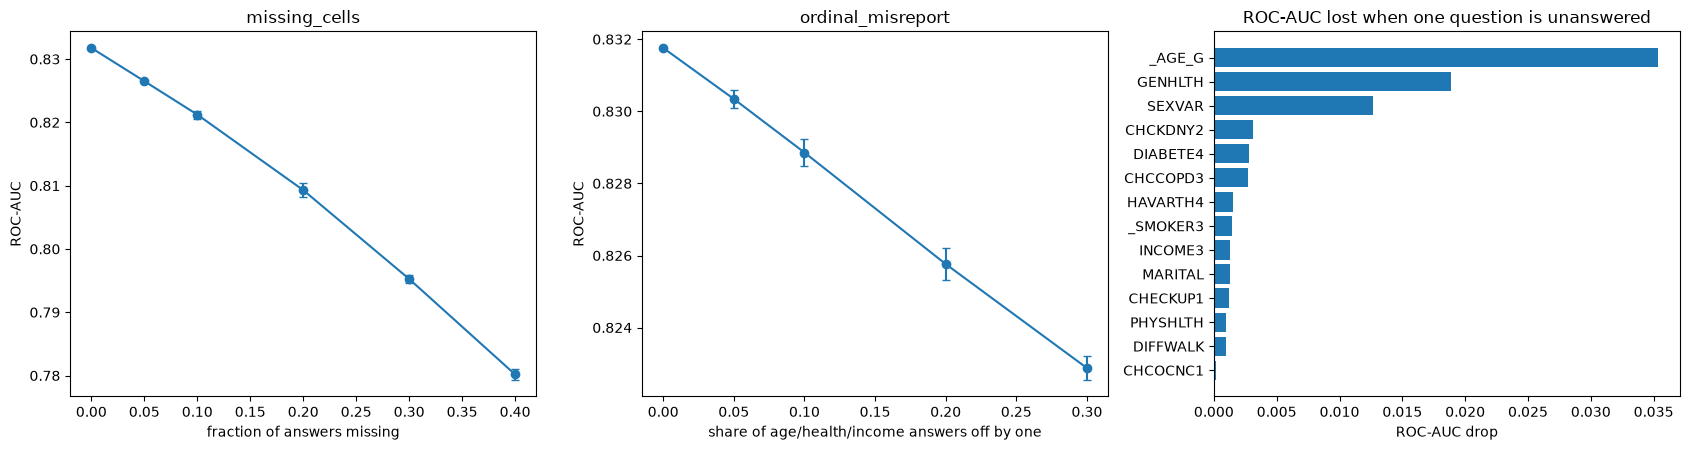

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
panels = [("missing_cells", ax[0], "fraction of answers missing"),
          ("ordinal_misreport", ax[1], "share of age/health/income answers off by one")]
for name, a, xlabel in panels:
    s = res[res.scenario == name].groupby("level")["roc_auc"].agg(["mean", "std"])
    a.errorbar([0] + list(s.index), [base["roc_auc"]] + list(s["mean"]),
               yerr=[0] + list(s["std"]), marker="o", capsize=3)
    a.set(xlabel=xlabel, ylabel="ROC-AUC", title=name)

order = ko["roc_auc_drop"].sort_values()
ax[2].barh(order.index, order.values)
ax[2].set(title="ROC-AUC lost when one question is unanswered", xlabel="ROC-AUC drop")

plt.tight_layout()
plt.savefig("../reports/figures/14_robustness.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
from src.robustness import knock_out
print("clean:", round(pipe.predict_proba(X_test[final])[:, 1].mean(), 4))
for c in ["CHCKDNY2", "CHCCOPD3", "MARITAL"]:
    p_ko = pipe.predict_proba(knock_out(X_test[final], c))[:, 1]
    print(c, "mean predicted risk when unanswered:", round(p_ko.mean(), 4))

clean: 0.0936
CHCKDNY2 mean predicted risk when unanswered: 0.1126
CHCCOPD3 mean predicted risk when unanswered: 0.1129
MARITAL mean predicted risk when unanswered: 0.0792


## Robustness findings

Controlled damage was applied to the test inputs only (model and threshold fixed; random scenarios repeated 5 times). Clean performance: ROC-AUC 0.832, PR-AUC 0.341, recall 0.798, 33.7% flagged.

**Missing answers.** ROC-AUC decreased steadily by about 0.001 per percentage point of answers removed (0.827 at 5%, 0.809 at 20%, 0.780 at 40% missing; PR-AUC −10% and −20% relative at 20% and 40%), with very small run-to-run variation (SD ≤ 0.001). The share of people flagged stayed at 33.8–34.1%, so the threshold remains usable with incomplete inputs, although recall at the fixed threshold fell (0.798 → 0.768 at 20%, 0.721 at 40%) and precision declined (0.221 → 0.211, 0.198).

**Misreported and noisy inputs.** When 30% of age, general-health and income answers were off by one category, ROC-AUC fell by only 0.009. Gaussian noise on days of poor physical health up to half its standard deviation changed ROC-AUC by ≤ 0.0004.

**Question dependence.** Leaving a single question unanswered for everyone cost most for age group (−0.035 ROC-AUC), general health (−0.019) and sex (−0.013); every other question cost ≤ 0.003. This is an inference-time test (the model is not retrained) and is not the same as training without the question.

**Whole-question omission shifts risk scores.** Leaving a question entirely blank changed the share flagged between roughly 28% and 40%, suggesting that the model treats a missing answer as an informative category learned from training; the demonstration app therefore requires all 14 answers.

**Limitation.** Missing values were injected completely at random; real non-response is not random, so this stress test is an optimistic proxy. It is a simulated experiment, not clinical validation.